In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr
import xarray as xr
import sys

sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
# from taylor_setup import *
from setup_diagnostic import *

In [3]:
# %% 1. Settings and the one user-supplied preprocessing function
import numpy as np
import xarray as xr
from pathlib import Path
from datetime import datetime, timezone

attr_core_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
attr_raw_dir = Path("/scratch/leiff/MCA/amip_clean/data")
attr_regional_path = attr_core_dir / "stationarity/regional/march_n178_regional.npy"
attr_run_dir = attr_core_dir / "stationarity/SEP_attribution/run_01"
attr_experiments = ["historical", "historical_matched", "amip_hist"]
attr_region, attr_index_key = "SEP", "cov_Zi_R"
attr_ddof, attr_min_windows = 1, 3
attr_save_monthly_indices = True  # Small (start_year, 178) arrays: A, Tg and Rg.
attr_confirmed_member_ids = None  # Optional {physical_experiment: {model: IDs in saved member order}}.
attr_resume = True              # True: reuse checked members in the SAME attr_run_dir.
attr_resume_legacy = True       # True ONLY to adopt files from the original, pre-resume notebook.

# REQUIRED BEFORE CALCULATING: import/paste YOUR detrend_monthly_fast here.
# It must remove the monthly climatology AND the month-specific linear trends,
# accept (time, lat, lon), and return that shape. All windows begin in March.
# For example, use the same project-function import as your stationarity notebook.
# No substitute detrending algorithm is silently installed by this notebook.

# The full running fields are large, so results are saved as each member finishes.
# New runs require a new directory. To resume, keep settings/preprocessing and
# attr_run_dir unchanged, set attr_resume=True, and rerun cells 1-7 AFTER the old
# calculation has stopped. Never run two writers against this directory.
# For the run already underway with the original notebook, also set
# attr_resume_legacy=True: those files lack a saved settings fingerprint, so
# you must confirm yourself that their settings/preprocessing are unchanged.
# No raw/stationarity files change. Complete saved members are not rewritten.
# For load/plot only: run cells 1, 2, 8, 9, then the desired plotting cells.
attr_complete = False




In [2]:
# %% 2. Small helpers: storage, alignment, averaging, and across-window fits
def attr_save_new(path, payload, *, replace=False):
    """Write fully to a temporary sibling file, then publish the finished bundle.

    Default refuses replacement. replace=True is only for regenerated model/
    MMM summaries and catalog during an explicit resume, not member outputs.
    """
    import os
    import tempfile
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and not replace:
        raise FileExistsError(path)
    temporary = None
    try:
        with tempfile.NamedTemporaryFile(dir=path.parent, prefix=f".{path.name}.", suffix=".tmp", delete=False) as handle:
            temporary = Path(handle.name)
            np.save(handle, payload, allow_pickle=True)
            handle.flush()
            os.fsync(handle.fileno())
        if replace:
            os.replace(temporary, path)
        else:
            os.link(temporary, path)  # Atomic publication; fails if the destination already exists.
    finally:
        if temporary is not None and temporary.exists():
            temporary.unlink()      # Only our own temporary file, never an existing result.


def attr_load_checkpoint(path, *, signature, quantity_info, sizes, fit_quantities,
                         label, raw_id, provenance, reference, local_reference,
                         weights, region_mask, min_windows, allow_legacy=False):
    """Return a checked member, or None if missing/unreadable/incomplete.

    Incompatible scientific settings, member labels, sources or reference
    indices STOP the run; they are not silently treated as missing output.
    """
    import pickle
    from uuid import uuid4
    path = Path(path)
    if not path.exists():
        return None

    # A timeout during the OLD direct writer can leave a truncated .npy. Preserve
    # it under a unique name for inspection, then recalculate this member.
    def incomplete(reason):
        backup = path.with_name(f"{path.name}.incomplete-{uuid4().hex[:12]}")
        path.rename(backup)
        print(f"  Incomplete checkpoint preserved as {backup.name}: {reason}", flush=True)
        return None

    try:
        saved = np.load(path, allow_pickle=True).item()
    except (EOFError, ValueError, pickle.UnpicklingError) as error:
        return incomplete(type(error).__name__)
    if not isinstance(saved, dict):
        return incomplete("not a member dictionary")
    previous_signature = saved.get("run_signature")
    if previous_signature is None and not allow_legacy:
        raise ValueError(f"{path}: legacy checkpoint. Keep original settings and explicitly set attr_resume_legacy=True to adopt it.")
    if previous_signature is not None and previous_signature != signature:
        raise ValueError(f"{path}: saved run settings differ. Use the original settings or a new run directory.")
    required = {"values", "fit_n_windows", "closure_max_abs_error", "member_label", "raw_member_id", "sources"}
    if not required <= saved.keys() or not all(isinstance(saved[k], dict) for k in ["values", "fit_n_windows", "sources", "closure_max_abs_error"]):
        return incomplete("missing member content")
    if str(saved["member_label"]) != str(label) or str(saved["raw_member_id"]) != str(raw_id):
        raise ValueError(f"{path}: member labels/order differ; do not mix these runs.")
    for variable in ["tas", "N"]:
        for key in ["path", "size_bytes", "mtime_ns", "units"]:
            if saved["sources"].get(variable, {}).get(key) != provenance[variable][key]:
                raise ValueError(f"{path}: {variable} source {key} changed; inspect before resuming.")
    values = saved["values"]
    if set(values) != set(quantity_info) or set(saved["fit_n_windows"]) != set(fit_quantities):
        raise ValueError(f"{path}: saved quantity set differs. Keep the original quantities or use a new run directory.")
    for key, info in quantity_info.items():
        value = np.asarray(values[key])
        shape = tuple(sizes[d] for d in info["dims"])
        if value.shape != shape or value.dtype.kind not in "fiu" or np.isinf(value).any():
            return incomplete(f"invalid values/shape for {key}")

    # Require complete basic budget fields and verify the original reference
    # index again. Standardized/correlation quantities can legitimately be NaN.
    support = weights > 0
    for key in ["D", "D_local_T", "D_residual", "sigma_Ti", "sigma_Ri"]:
        if not np.isfinite(values[key][..., support]).all():
            return incomplete(f"missing budget cells in {key}")
    for key in fit_quantities:
        if quantity_info[key]["kind"] == "series" and not np.isfinite(values[key]).all():
            return incomplete(f"missing windows in {key}")
        n = np.asarray(saved["fit_n_windows"][key])
        response = np.asarray(values[key])
        expected_n = np.isfinite(response).sum(axis=0)  # I must be finite at every window.
        if n.shape != response.shape[1:] or not np.array_equal(n, expected_n):
            return incomplete(f"invalid window counts for {key}")
        if np.ptp(values["I"]) > 0 and np.any((n == len(reference)) & (n >= min_windows) & ~np.isfinite(values[f"slope_{key}"])):
            return incomplete(f"missing eligible slopes for {key}")
    attr_check(values["I"], reference, f"{path.name}: archived SEP index")
    if local_reference is not None:
        attr_check(values["local_diag_mean"], local_reference, f"{path.name}: archived local-local index")
    w = weights[support]
    regional_weights = weights[region_mask]
    attr_check(np.sum(values["cov_Zi_R"][..., region_mask]*regional_weights/regional_weights.sum(), axis=-1),
               values["I"], "resumed member SEP weights/index")
    attr_check(np.sum(values["D"][..., support]*w, axis=-1), values["I"], "resumed member global budget")
    attr_check((values["D_local_T"] + values["D_residual"])[..., support], values["D"][..., support], "resumed member projection")
    attr_check(values["I_SEP"] + values["I_outside"], values["I"], "resumed member region split")
    attr_check(values["I_diag"] + values["I_SEP_cross"], values["I_SEP"], "resumed member within-region split")
    if previous_signature is None:
        print("  Adopting legacy checkpoint: labels, source files, shapes, indices and budgets checked; original preprocessing/settings assumed.", flush=True)
    return saved


def attr_mean_update(total, count, values):
    """Accumulate one member/model at a time; counts preserve missing support."""
    for key, value in values.items():
        value = np.asarray(value, dtype=float)
        if key not in total:
            total[key], count[key] = np.zeros_like(value), np.zeros(value.shape, dtype=np.int32)
        if total[key].shape != value.shape:
            raise ValueError(f"{key}: inconsistent shapes during aggregation.")
        finite = np.isfinite(value)
        total[key] += np.where(finite, value, 0.)
        count[key] += finite


def attr_mean_finish(total, count):
    return {key: np.divide(value, count[key], out=np.full_like(value, np.nan), where=count[key] > 0)
            for key, value in total.items()}


def attr_prepare_raw(field, months, lat, lon):
    """Validate dates/grid, then expose canonical (member,time,lat,lon) axes."""
    field = field.sel(time=slice(str(months[0]), str(months[-1])))
    actual = np.asarray(field.time.dt.year*12 + field.time.dt.month - 1)
    if not np.array_equal(actual, months.astype(int) + 1970*12):
        raise ValueError(f"{field.name}: missing, repeated, or reordered months.")
    for dimension, expected in [("lat", lat), ("lon", lon)]:
        actual = np.asarray(field[dimension])
        if actual.shape != expected.shape or not np.allclose(actual, expected, rtol=0, atol=1e-6):
            raise ValueError(f"{field.name}: {dimension} differs from the regional archive.")
    extra = [d for d in field.dims if d not in ["time", "lat", "lon"]]
    if len(extra) > 1:
        raise ValueError(f"Select extra dimensions explicitly: {field.dims}")
    if extra:
        dim = extra[0]
        ids = np.asarray(field[dim]).astype(str) if dim in field.coords else np.arange(field.sizes[dim]).astype(str)
        field = field.rename({dim: "member"}) if dim != "member" else field
        field = field.assign_coords(member=ids)
    else:
        field = field.expand_dims(member=["single"])
    if len(set(field.member.values.tolist())) != field.sizes["member"]:
        raise ValueError("Duplicate raw member labels.")
    return field.transpose("member", "time", "lat", "lon")


def attr_fit(index, response, min_windows=3):
    """Regress response(s,...) ON index(s); intercept included, no p-values.

    Counts are paired windows, NOT independent sample sizes. The standardized
    slope uses one index SD over all finite windows, not a cell-specific SD.
    """
    index, response = np.asarray(index, dtype=float), np.asarray(response, dtype=float)
    if index.ndim != 1 or response.shape[0] != len(index) or min_windows < 3:
        raise ValueError("Expected matching window axes and min_windows >= 3.")
    x = index.reshape((len(index),) + (1,)*(response.ndim - 1))
    paired = np.isfinite(x) & np.isfinite(response)
    n = paired.sum(axis=0)
    mx = np.divide(np.where(paired, x, 0.).sum(axis=0), n, out=np.zeros(response.shape[1:]), where=n > 0)
    my = np.divide(np.where(paired, response, 0.).sum(axis=0), n, out=np.zeros(response.shape[1:]), where=n > 0)
    dx, dy = np.where(paired, x, mx) - mx, np.where(paired, response, my) - my
    xx, yy, xy = np.sum(dx*dx, axis=0), np.sum(dy*dy, axis=0), np.sum(dx*dy, axis=0)
    varying_x = np.max(np.where(paired, x, -np.inf), axis=0) > np.min(np.where(paired, x, np.inf), axis=0)
    varying_y = np.max(np.where(paired, response, -np.inf), axis=0) > np.min(np.where(paired, response, np.inf), axis=0)
    fit_ok = (n >= min_windows) & varying_x & (xx > 0)
    xy = np.where(varying_y, xy, 0.)
    slope = np.divide(xy, xx, out=np.full_like(xx, np.nan), where=fit_ok)
    denominator = np.sqrt(xx)*np.sqrt(yy)
    corr = np.divide(xy, denominator, out=np.full_like(xx, np.nan), where=fit_ok & varying_y & (denominator > 0))
    finite_index = index[np.isfinite(index)]
    sd = float(np.std(finite_index, ddof=1)) if finite_index.size >= 2 else np.nan
    if finite_index.size and np.ptp(finite_index) == 0:
        sd = 0.
    return {"slope": slope, "corr": np.clip(corr, -1., 1.),
            "intercept": np.where(fit_ok, my - slope*mx, np.nan), "slope_per_index_sd": slope*sd}, n


def attr_check(left, right, label, rtol=1e-8, atol=1e-10):
    """A scientific closure/alignment check, with an error useful for inspection."""
    left, right = np.asarray(left), np.asarray(right)
    if left.shape != right.shape or not np.allclose(left, right, rtol=rtol, atol=atol, equal_nan=False):
        raise ValueError(f"Failed {label}; check preprocessing, support, dates and member alignment.")
    return float(np.max(np.abs(left - right)))




In [4]:
# %% 3. Reuse the archived grid, region, years and member definitions
attr_regional = np.load(attr_regional_path, allow_pickle=True).item()
attr_meta = attr_regional["metadata"]
attr_years = np.asarray(attr_meta["start_years"])
attr_starts = np.asarray(attr_meta["start_months"], dtype="datetime64[M]")
attr_ends = np.asarray(attr_meta["end_months"], dtype="datetime64[M]")
attr_length = int(attr_meta["window_months"])
attr_lat, attr_lon = [np.asarray(attr_meta[k], dtype=float) for k in ["lat", "lon"]]
if (attr_years.ndim != 1 or len(attr_years) < attr_min_windows or attr_length != 178 or attr_ddof != 1
        or attr_starts.shape != attr_years.shape or attr_ends.shape != attr_years.shape
        or np.any(np.diff(attr_years) != 1) or np.any(attr_starts.astype(int) % 12 != 2)
        or not np.array_equal(attr_starts.astype("datetime64[Y]").astype(int) + 1970, attr_years)
        or not np.array_equal(attr_ends, attr_starts + np.timedelta64(177, "M"))):
    raise ValueError("Expected consecutive March-start, 178-month windows and ddof=1.")
if any(v.ndim != 1 or not np.isfinite(v).all() for v in [attr_lat, attr_lon]):
    raise ValueError("Expected finite one-dimensional lat/lon coordinates.")
attr_months = np.arange(attr_starts[0], attr_ends[-1] + np.timedelta64(1, "M"))
attr_window_starts = (attr_starts - attr_months[0]).astype(int)
attr_shape = (len(attr_lat), len(attr_lon))
attr_weights = np.ma.asarray(attr_meta["weights"], dtype=float).filled(np.nan)
region = np.ma.asarray(attr_regional["regions"][attr_region], dtype=float).filled(np.nan)
if attr_weights.shape != attr_shape or region.shape != attr_shape or np.any(attr_weights < 0):
    raise ValueError("Region and nonnegative area weights must match the archived grid.")
attr_weights = np.where(np.isfinite(attr_weights) & (attr_weights > 0), attr_weights, 0.)
if attr_weights.sum() <= 0:
    raise ValueError("No positive area weights.")
attr_weights /= attr_weights.sum()
attr_support = attr_weights > 0
attr_mask = np.isfinite(region) & (region != 0) & attr_support
if not attr_mask.any():
    raise ValueError("Region contains no supported cells.")
attr_p = np.where(attr_mask, attr_weights, 0.)
attr_p /= attr_p.sum()  # Only the predictor average is REGION-normalized.

# Historical matched uses the exact same coupled members/files, but gets its
# own equal-model MMM. A member of AMIP is never paired with a coupled member.
allowed = {"historical", "historical_matched", "amip_hist"}
if not attr_experiments or len(set(attr_experiments)) != len(attr_experiments) or not set(attr_experiments) <= allowed:
    raise ValueError("Choose a unique subset of the three experiment names.")
attr_models = {e: list(attr_meta["model_names"][e]) for e in attr_experiments}
attr_jobs, attr_source_group = {}, {}
for experiment, models in attr_models.items():
    if not models or len(set(models)) != len(models):
        raise ValueError(f"{experiment}: empty or duplicated model names.")
    for model in models:
        physical = "amip_hist" if experiment == "amip_hist" else "historical"
        attr_source_group[experiment, model] = physical
        attr_jobs.setdefault((physical, model), []).append(experiment)
if allowed <= set(attr_experiments):
    if set(attr_models["historical_matched"]) != set(attr_models["historical"]) & set(attr_models["amip_hist"]):
        raise ValueError("historical_matched must be the intersection of the other model sets.")

# These are ALL running maps. Each stored member array has (start_year,lat,lon).
# 'Cov(A,Z)' and 'Cov(A,Q)' are not correlations: A has NOT been restandardized.
attr_map_definitions = {
    "D": ("W m-2", "Cov(A,Ri): radiation-origin map; global area sum equals I"),
    "cov_A_Zi": ("1", "Cov(A,Zi): co-variability of local standardized temperature with SEP"),
    "cov_A_Ti": ("K", "Cov(A,Ti): temperature co-variability retaining local amplitude"),
    "cov_A_Qi": ("1", "Cov(A,Qi): radiation co-variability without local radiation amplitude"),
    "corr_A_Ti": ("1", "Pearson correlation of monthly A with local temperature"),
    "corr_A_Ri": ("1", "Pearson correlation of monthly A with local radiation"),
    "cov_Zi_Ri": ("W m-2", "B = Cov(Zi,Ri), the local regression onto standardized T"),
    "D_local_T": ("W m-2", "B*Cov(A,Zi): local-temperature-associated part of D"),
    "D_residual": ("W m-2", "Cov(A,e), where e = Ri-B*Zi; not a causal attribution"),
    "sigma_Ti": ("K", "Within-window detrended local temperature SD"),
    "sigma_Ri": ("W m-2", "Within-window detrended local radiation SD"),
    "cov_Zi_T": ("K", "Cov(Zi,Tg): secondary global-temperature context map"),
    "cov_Qi_R": ("W m-2", "Cov(Qi,Rg): secondary global-radiation context map"),
    "cov_Zi_R": ("W m-2", "Original diagnostic Cov(Zi,Rg), whose SEP mean is I"),
}
attr_series_definitions = {
    "I": ("W m-2", "SEP cov_Zi_R index, equal to Cov(A,Rg)"),
    "I_SEP": ("W m-2", "Global-weighted D sum INSIDE SEP, without regional renormalization"),
    "I_outside": ("W m-2", "Global-weighted D sum OUTSIDE SEP"),
    "I_diag": ("W m-2", "Same-grid-cell contribution sum_SEP(p_i*w_i*B_i)"),
    "I_SEP_cross": ("W m-2", "Within-SEP cross-grid-cell contribution: I_SEP-I_diag"),
    "I_local_T": ("W m-2", "Global sum of D_local_T"),
    "I_residual": ("W m-2", "Global sum of D_residual"),
    "local_diag_mean": ("W m-2", "SEP mean of B; NOT a global-radiation budget contribution"),
    "sigma_A": ("1", "Monthly SD of A; reflects coherence of standardized SEP temperatures"),
    "sigma_T": ("K", "Monthly SD of global temperature in this window"),
    "sigma_R": ("W m-2", "Monthly SD of global radiation in this window"),
}
attr_quantity_info = {}
for kind, definitions in [("running_map", attr_map_definitions), ("series", attr_series_definitions)]:
    dims = ("start_year", "lat", "lon") if kind == "running_map" else ("start_year",)
    for key, (unit, meaning) in definitions.items():
        attr_quantity_info[key] = {"kind": kind, "dims": dims, "units": unit, "meaning": meaning}
attr_fit_quantities = list(attr_quantity_info)
for key in attr_fit_quantities:
    info = attr_quantity_info[key]
    for statistic in ["slope", "corr", "intercept", "slope_per_index_sd"]:
        unit = "1" if statistic == "corr" else (f"({info['units']}) / (W m-2)" if statistic == "slope" else info["units"])
        attr_quantity_info[f"{statistic}_{key}"] = {"kind": "map" if info["kind"] == "running_map" else "scalar",
            "dims": info["dims"][1:], "units": unit, "meaning": f"Across-window {statistic} of {key} ON own-member I"}
if attr_save_monthly_indices:
    for key, unit in [("A", "1"), ("Tg", "K"), ("Rg", "W m-2")]:
        attr_quantity_info[key] = {"kind": "window_monthly", "dims": ("start_year", "month_in_window"),
                                  "units": unit, "meaning": f"Processed monthly {key} inside each window"}

# YOUR NEW DIAGNOSTIC: register a running map/series above, assign it in the
# one-window function below. Storage, fits and aggregation then include it.
# At the default grid each member's 14 running maps occupy about 152 MB in
# float64. The model/ MMM files are additional; no ensemble-size pooling occurs.
print(f"{len(attr_jobs)} unique model/experiment jobs; {len(attr_years)} windows each.")




69 unique model/experiment jobs; 131 windows each.


In [5]:
# %% 4. One window: exact radiation budget and its local-temperature projection
def attr_one_window(raw_T, raw_R, weights, region_mask, preprocess, ddof=1):
    """Return this window's maps, scalars, monthly indices and closure errors.

    Missing months on positive-weight cells are refused: changing support would
    change the budget. Zero-weight cells are excluded throughout. R/N keeps its
    input sign. This is statistical attribution, not a causal feedback estimate.
    """
    support = weights > 0
    region_mask = region_mask & support
    p = np.where(region_mask, weights, 0.)
    p /= p.sum()
    processed = []
    for raw in [raw_T, raw_R]:
        raw = np.asarray(raw, dtype=float)
        if raw.ndim != 3 or raw.shape[1:] != weights.shape or not np.isfinite(raw[:, support]).all():
            raise ValueError("Each raw window must have complete months on the fixed weighted domain.")
        # A fresh array protects overlapping raw windows from an in-place function.
        # Excluded cells are zero placeholders only during monthly preprocessing.
        field = np.asarray(preprocess(np.where(support[None], raw, 0.)), dtype=float)
        if field.shape != raw.shape or not np.isfinite(field[:, support]).all():
            raise ValueError("detrend_monthly_fast returned invalid shape/values.")
        field = field - field.mean(axis=0)
        processed.append(np.where(support[None], field, 0.))
    Ti, Ri = processed
    n = len(Ti)
    if len(Ri) != n or n <= ddof:
        raise ValueError("T/R window lengths do not agree.")
    covariance = lambda a, b: np.sum(a*b, axis=0)/(n - ddof)
    sigma_Ti, sigma_Ri = [np.std(field, axis=0, ddof=ddof) for field in [Ti, Ri]]
    # Treat exactly constant processed series as zero variance even if floating-
    # point averaging has left a tiny constant residual.
    sigma_Ti = np.where(np.ptp(Ti, axis=0) > 0, sigma_Ti, 0.)
    sigma_Ri = np.where(np.ptp(Ri, axis=0) > 0, sigma_Ri, 0.)
    variable_T, variable_R = support & (sigma_Ti > 0), support & (sigma_Ri > 0)
    if not variable_T[region_mask].all():
        raise ValueError("A SEP cell has no temperature variance; its standardized index is undefined.")
    Zi = np.divide(Ti, sigma_Ti, out=np.zeros_like(Ti), where=variable_T)
    Qi = np.divide(Ri, sigma_Ri, out=np.zeros_like(Ri), where=variable_R)
    Tg, Rg = [np.sum(field*weights, axis=(1, 2)) for field in [Ti, Ri]]
    A = np.sum(Zi*p, axis=(1, 2))  # Average standardized T; do NOT standardize A again.
    sigma_A = float(np.std(A, ddof=ddof)) if np.ptp(A) > 0 else 0.
    a, rg, tg = A[:, None, None], Rg[:, None, None], Tg[:, None, None]

    # 1. D answers WHERE radiation co-varies with SEP temperatures. Its global
    # area mean exactly reconstructs the original SEP cov_Zi_R scalar I.
    D, I = covariance(a, Ri), covariance(A, Rg)
    B, C = covariance(Zi, Ri), covariance(a, Zi)
    cov_Zi_R = covariance(Zi, rg)
    cov_A_Qi, cov_Qi_R = covariance(a, Qi), covariance(Qi, rg)

    # 2-4. Separate temperature co-variability, radiation amplitude, and the
    # part captured by each grid cell's local T projection: Ri = B*Zi + e.
    # Constant T outside SEP has a zero-dimensional predictor space: fitted=0,
    # residual=Ri. Standardized-T diagnostics themselves are NaN at those cells.
    D_local_T = B*C
    e = Ri - B[None]*Zi
    D_residual = covariance(a, e)  # Direct calculation gives an independent closure check.
    corr_A_Ti = np.divide(C, sigma_A, out=np.full_like(C, np.nan), where=variable_T & (sigma_A > 0))
    corr_A_Ri = np.divide(cov_A_Qi, sigma_A, out=np.full_like(D, np.nan), where=variable_R & (sigma_A > 0))
    maps = {"D": D, "cov_A_Zi": np.where(variable_T, C, np.nan), "cov_A_Ti": covariance(a, Ti),
            "cov_A_Qi": np.where(variable_R, cov_A_Qi, np.nan),
            "corr_A_Ti": np.clip(corr_A_Ti, -1., 1.), "corr_A_Ri": np.clip(corr_A_Ri, -1., 1.),
            "cov_Zi_Ri": np.where(variable_T, B, np.nan), "D_local_T": D_local_T, "D_residual": D_residual,
            "sigma_Ti": sigma_Ti, "sigma_Ri": sigma_Ri, "cov_Zi_T": np.where(variable_T, covariance(Zi, tg), np.nan),
            "cov_Qi_R": np.where(variable_R, cov_Qi_R, np.nan), "cov_Zi_R": np.where(variable_T, cov_Zi_R, np.nan)}
    I_SEP, I_outside = np.sum(weights[region_mask]*D[region_mask]), np.sum(weights[support & ~region_mask]*D[support & ~region_mask])
    I_diag = np.sum(p[region_mask]*weights[region_mask]*B[region_mask])
    series = {"I": I, "I_SEP": I_SEP, "I_outside": I_outside, "I_diag": I_diag,
              "I_SEP_cross": I_SEP-I_diag, "I_local_T": np.sum(weights*D_local_T),
              "I_residual": np.sum(weights*D_residual), "local_diag_mean": np.sum(p*B),
              "sigma_A": sigma_A, "sigma_T": np.std(Tg, ddof=ddof), "sigma_R": np.std(Rg, ddof=ddof)}
    checks = {
        "D_global_equals_I": attr_check(np.sum(weights*D), I, "global D sum = I"),
        "regional_index": attr_check(np.sum(p*cov_Zi_R), I, "SEP cov_Zi_R mean = I"),
        "D_projection": attr_check((D_local_T + D_residual)[support], D[support], "D_local_T+D_residual=D"),
        "radiation_amplitude": attr_check((sigma_Ri*cov_A_Qi)[support], D[support], "sigma_Ri*Cov(A,Qi)=D"),
        "radiation_variance": attr_check(np.sum(weights*sigma_Ri*cov_Qi_R), np.var(Rg, ddof=ddof), "global R variance budget"),
        "SEP_and_outside": attr_check(I_SEP + I_outside, I, "SEP + outside = I"),
        "projection_global": attr_check(series["I_local_T"] + series["I_residual"], I, "global projection split"),
        "e_orthogonal_Zi": attr_check(covariance(Zi, e)[support], np.zeros(support.sum()), "local residual orthogonality"),
    }
    maps = {key: np.where(support, value, np.nan) for key, value in maps.items()}
    return maps | series, {"A": A, "Tg": Tg, "Rg": Rg}, checks




In [6]:
# %% 5. Calculate and save each member, then average members within its model
if not callable(globals().get("detrend_monthly_fast")):
    raise NameError("Import/paste your detrend_monthly_fast before running the calculation cell.")
if attr_run_dir.exists() and not attr_resume:
    raise FileExistsError(f"To restart this unchanged run, set attr_resume=True; otherwise choose a new directory: {attr_run_dir}")
attr_run_dir.mkdir(parents=True, exist_ok=attr_resume)
attr_complete = False
attr_manifest = {"member_files": {e: {} for e in attr_experiments}, "model_files": {e: {} for e in attr_experiments},
                 "MMM_files": {}, "model_names": attr_models, "member_labels": {e: {} for e in attr_experiments},
                 "quantity_info": attr_quantity_info, "coordinates": {"lat": attr_lat, "lon": attr_lon,
                 "start_year": attr_years, "start_month": attr_starts, "end_month": attr_ends,
                 "month_in_window": np.arange(attr_length)}, "weights": attr_weights, "region_mask": attr_mask,
                 "metadata": {"region": attr_region, "index_key": attr_index_key, "ddof": attr_ddof,
                 "window_months": attr_length, "min_windows": attr_min_windows, "regional_source": str(attr_regional_path),
                 "created_utc": datetime.now(timezone.utc).isoformat(), "schema": "SEP_attribution_v1",
                 "preprocessing": "User detrend_monthly_fast inside each March-start window, followed by recentering",
                 "aggregation": "Arithmetic member diagnostics -> model mean -> equal-model MMM; finite counts retained",
                 "across_window_fit": "OLS with intercept ON own-member I; no extra detrend, no p-values",
                 "interpretation": "Statistical covariance attribution, not proof of causal feedback/teleconnection"}}
# Record the actual function source when Python can retrieve it (not guaranteed
# for notebook-defined functions). The user function itself is never serialized.
import inspect
try:
    attr_manifest["metadata"]["detrend_function_source"] = inspect.getsource(detrend_monthly_fast)
except (OSError, TypeError):
    attr_manifest["metadata"]["detrend_function_source"] = "Not retrievable; retain your preprocessing cell."

# New member files carry a fingerprint of the numerical settings. Legacy files
# from the already-running notebook do not: adopting those is explicit opt-in.
# If source retrieval is unavailable, keep the SAME preprocessing function;
# a fingerprint cannot verify source code it was unable to retrieve.
import hashlib
import json
attr_settings = {"schema": "SEP_attribution_v1", "coordinates": attr_manifest["coordinates"],
                 "weights": attr_weights, "region_mask": attr_mask, "region": attr_region,
                 "index_key": attr_index_key, "ddof": attr_ddof, "min_windows": attr_min_windows,
                 "quantity_info": attr_quantity_info,
                 "detrend_function_source": attr_manifest["metadata"]["detrend_function_source"]}
def attr_json_array(array):
    if not isinstance(array, np.ndarray):
        raise TypeError(f"Unexpected settings type: {type(array)}")
    values = array.astype(str).tolist() if array.dtype.kind in "Mm" else array.tolist()
    return {"dtype": str(array.dtype), "values": values}

attr_settings_text = json.dumps(attr_settings, sort_keys=True, default=attr_json_array, allow_nan=False, separators=(",", ":"))
attr_signature = hashlib.sha256(attr_settings_text.encode()).hexdigest()
attr_manifest["metadata"]["run_signature"] = attr_signature
attr_manifest["metadata"]["resume_enabled"] = attr_resume
attr_manifest["metadata"]["legacy_resume_allowed"] = attr_resume_legacy
attr_sizes = {"start_year": len(attr_years), "lat": len(attr_lat), "lon": len(attr_lon), "month_in_window": attr_length}

for (physical, model), aliases in attr_jobs.items():
    print(f"{physical} / {model}", flush=True)
    experiment = aliases[0]
    reference = np.asarray(attr_regional["member_values"][experiment][attr_index_key][attr_region][model], dtype=float)
    labels = np.asarray(attr_meta["member_labels"][experiment][model])
    if reference.ndim != 2 or reference.shape[1] != len(attr_years) or len(reference) < 1 or not np.isfinite(reference).all():
        raise ValueError(f"{experiment}/{model}: need finite (member,start_year) reference indices.")
    n_members = len(reference)
    if labels.shape != (n_members,) or len(set(labels.tolist())) != n_members:
        raise ValueError(f"{model}: invalid archived member labels.")
    for alias in aliases:
        attr_check(np.asarray(attr_regional["member_values"][alias][attr_index_key][attr_region][model]), reference, f"{model}: historical aliases")
        if not np.array_equal(attr_meta["member_labels"][alias][model], labels):
            raise ValueError(f"{model}: historical/matched member order differs.")

    # Open each raw file ONCE; load just one complete raw member at a time.
    folder, tag = ("AMIP", "amip-hist") if physical == "amip_hist" else ("HIST", "historical")
    paths = {}
    for variable in ["tas", "N"]:
        candidates = sorted((attr_raw_dir / folder / model).glob(f"{variable}_Amon_{model}_*{tag}*combined*187001-201412_g025.nc"))
        if len(candidates) != 1:
            raise ValueError(f"{model}/{variable}: expected one raw file, found {candidates}.")
        paths[variable] = candidates[0]
    provenance = {v: {"path": str(p), "size_bytes": p.stat().st_size, "mtime_ns": p.stat().st_mtime_ns} for v, p in paths.items()}
    totals, counts, member_files = {}, {}, []
    with xr.open_dataset(paths["tas"]) as ds_T, xr.open_dataset(paths["N"]) as ds_R:
        fields = {"tas": attr_prepare_raw(ds_T["tas"], attr_months, attr_lat, attr_lon),
                  "N": attr_prepare_raw(ds_R["N"], attr_months, attr_lat, attr_lon)}
        ids = None if attr_confirmed_member_ids is None else np.asarray(attr_confirmed_member_ids[physical][model]).astype(str)
        if ids is None and attr_meta.get("member_label_kind") == "user-confirmed member IDs":
            ids = labels.astype(str)
        if ids is not None:
            if ids.shape != (n_members,) or len(set(ids.tolist())) != n_members:
                raise ValueError(f"{model}: invalid confirmed member IDs.")
            fields = {v: field.sel(member=ids) for v, field in fields.items()}
        if any(field.sizes["member"] != n_members for field in fields.values()) or not np.array_equal(fields["tas"].member, fields["N"].member):
            raise ValueError(f"{model}: member counts/order differ. Supply confirmed stationarity member IDs.")
        provenance["alignment"] = "confirmed IDs" if ids is not None else "assumed original file positions; checked against regional series"
        allowed_units = {"tas": {"K", "kelvin", "Kelvin"}, "N": {"W m-2", "W m^-2", "W m**-2", "W/m2", "W/m^2", "W m−2"}}
        for variable, field in fields.items():
            unit = field.attrs.get("units")
            if unit is not None and unit not in allowed_units[variable]:
                raise ValueError(f"{model}/{variable}: convert units {unit!r} explicitly.")
            provenance[variable]["units"] = unit or "Missing label: assumed K for tas, W m-2 for N"

        for member in range(n_members):
            print(f"  member {member + 1}/{n_members}", flush=True)
            member_path = Path("members") / physical / model / f"member_{member:03d}.npy"
            local_reference = None
            for alias in aliases:
                local = attr_regional["member_values"][alias].get("cov_Zi_Ri", {}).get(attr_region, {}).get(model)
                if local is not None:
                    if local_reference is not None:
                        attr_check(np.asarray(local)[member], local_reference, f"{model}: local-local historical aliases")
                    local_reference = np.asarray(local)[member]

            # Restart check BEFORE loading raw member fields or processing any
            # windows. Still add saved values to totals: a bare 'continue' here
            # would incorrectly omit completed members from the rebuilt means.
            if attr_resume:
                saved = attr_load_checkpoint(attr_run_dir / member_path, signature=attr_signature,
                    quantity_info=attr_quantity_info, sizes=attr_sizes, fit_quantities=attr_fit_quantities,
                    label=labels[member], raw_id=str(fields["tas"].member.values[member]), provenance=provenance,
                    reference=reference[member], local_reference=local_reference, weights=attr_weights,
                    region_mask=attr_mask, min_windows=attr_min_windows, allow_legacy=attr_resume_legacy)
                if saved is not None:
                    attr_mean_update(totals, counts, saved["values"])
                    member_files.append(str(member_path))
                    print("    Reusing complete member; no monthly recalculation.", flush=True)
                    del saved
                    continue
            raw_T, raw_R = [np.asarray(fields[v].isel(member=member).values, dtype=float) for v in ["tas", "N"]]
            values = {q: np.full((len(attr_years),) + (attr_shape if q in attr_map_definitions else ()), np.nan)
                      for q in attr_fit_quantities}
            if attr_save_monthly_indices:
                values.update({q: np.full((len(attr_years), attr_length), np.nan) for q in ["A", "Tg", "Rg"]})
            closure_errors = {}
            for s, start in enumerate(attr_window_starts):
                window = slice(start, start + attr_length)
                here, monthly, errors = attr_one_window(raw_T[window], raw_R[window], attr_weights, attr_mask, detrend_monthly_fast, attr_ddof)
                for key in attr_fit_quantities:
                    values[key][s] = here[key]
                if attr_save_monthly_indices:
                    for key in monthly:
                        values[key][s] = monthly[key]
                for key, error in errors.items():
                    closure_errors[key] = max(closure_errors.get(key, 0.), error)
            del raw_T, raw_R

            # This is the important bridge to the existing plots: same years,
            # member, monthly processing, spatial standardization and SEP weights.
            closure_errors["archived_I"] = attr_check(values["I"], reference[member], f"{model}/{member}: archived SEP index")
            for alias in aliases:
                local = attr_regional["member_values"][alias].get("cov_Zi_Ri", {}).get(attr_region, {}).get(model)
                if local is not None:
                    closure_errors["archived_local_diag"] = attr_check(values["local_diag_mean"], np.asarray(local)[member], "archived SEP cov_Zi_Ri")

            # Compute every relationship PER MEMBER before any ensemble/model
            # averaging. A correlation map is not an additive budget map.
            fit_n_windows = {}
            for quantity in attr_fit_quantities:
                fitted, fit_n_windows[quantity] = attr_fit(values["I"], values[quantity], attr_min_windows)
                values.update({f"{stat}_{quantity}": result for stat, result in fitted.items()})
            if np.ptp(values["I"]) > 0:
                closure_errors["slope_D_global"] = attr_check(np.sum(attr_weights[attr_support]*values["slope_D"][attr_support]), np.asarray(1.), "global slope_D = 1")
                closure_errors["slope_projection"] = attr_check((values["slope_D_local_T"] + values["slope_D_residual"])[attr_support], values["slope_D"][attr_support], "slope projection closure")
            attr_save_new(attr_run_dir / member_path, {"values": values, "fit_n_windows": fit_n_windows,
                "closure_max_abs_error": closure_errors, "member_label": labels[member],
                "raw_member_id": str(fields["tas"].member.values[member]), "sources": provenance,
                "run_signature": attr_signature})
            member_files.append(str(member_path))
            attr_mean_update(totals, counts, values)
            del values

    # Model means are diagnostics averaged across members, including SDs and
    # correlations. They are NOT diagnostics recalculated from mean fields.
    model_path = Path("models") / physical / f"{model}.npy"
    attr_save_new(attr_run_dir / model_path, {"values": attr_mean_finish(totals, counts), "n_valid": counts,
                                            "n_members": n_members, "member_labels": labels}, replace=attr_resume)
    del totals, counts
    for alias in aliases:
        attr_manifest["member_files"][alias][model] = member_files.copy()
        attr_manifest["model_files"][alias][model] = str(model_path)
        attr_manifest["member_labels"][alias][model] = labels.copy()




historical / ACCESS-CM2
  member 1/3
  Adopting legacy checkpoint: labels, source files, shapes, indices and budgets checked; original preprocessing/settings assumed.
    Reusing complete member; no monthly recalculation.
  member 2/3
  Adopting legacy checkpoint: labels, source files, shapes, indices and budgets checked; original preprocessing/settings assumed.
    Reusing complete member; no monthly recalculation.
  member 3/3
  Adopting legacy checkpoint: labels, source files, shapes, indices and budgets checked; original preprocessing/settings assumed.
    Reusing complete member; no monthly recalculation.
historical / ACCESS-ESM1-5
  member 1/30
  Adopting legacy checkpoint: labels, source files, shapes, indices and budgets checked; original preprocessing/settings assumed.
    Reusing complete member; no monthly recalculation.
  member 2/30
  Adopting legacy checkpoint: labels, source files, shapes, indices and budgets checked; original preprocessing/settings assumed.
    Reusing 

In [7]:
# %% 6. Equal-model MMMs: historical matched stays a separate model population
for experiment in attr_experiments:
    totals, counts = {}, {}
    for model in attr_models[experiment]:
        bundle = np.load(attr_run_dir / attr_manifest["model_files"][experiment][model], allow_pickle=True).item()
        attr_mean_update(totals, counts, bundle["values"])
        del bundle
    path = Path("MMM") / f"{experiment}.npy"
    attr_save_new(attr_run_dir / path, {"values": attr_mean_finish(totals, counts), "n_valid": counts,
                                      "model_names": attr_models[experiment]})
    attr_manifest["MMM_files"][experiment] = str(path)
    del totals, counts
attr_complete = True




In [8]:
# %% 7. Final save: publish the small catalog only after all results are complete
if not attr_complete:
    raise RuntimeError("Finish the member/model and MMM cells before saving the catalog.")
attr_save_new(attr_run_dir / "catalog.npy", attr_manifest)
print(f"Saved catalog and member/model/MMM bundles under {attr_run_dir}")




Saved catalog and member/model/MMM bundles under /scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/stationarity/SEP_attribution/run_01


In [9]:
# %% 8. Load block and a small accessor (also run this after a fresh calculation)
# Trusted files only: these NumPy dictionaries use pickle. The catalog contains
# RELATIVE paths, so the entire run directory can be moved/copied together.
attr_catalog = np.load(attr_run_dir / "catalog.npy", allow_pickle=True).item()

def load_attr_bundle(experiment, model=None, member=None, *, catalog=None, directory=None):
    """MMM if model omitted; model mean if member omitted; otherwise one member.

    member is a zero-based POSITION in catalog['member_labels'][experiment][model].
    Each bundle has ['values'][quantity]; member files also contain fit counts,
    closure checks and raw-file provenance. Model/MMM files have n_valid counts.
    """
    catalog = attr_catalog if catalog is None else catalog
    directory = attr_run_dir if directory is None else Path(directory)
    if model is None:
        if member is not None:
            raise ValueError("Specify a model when requesting a member.")
        path = catalog["MMM_files"][experiment]
    elif member is None:
        path = catalog["model_files"][experiment][model]
    else:
        paths = catalog["member_files"][experiment][model]
        if not isinstance(member, (int, np.integer)) or not 0 <= member < len(paths):
            raise IndexError("Member must be a valid zero-based position.")
        path = paths[member]
    return np.load(directory / path, allow_pickle=True).item()

# Examples (uncomment only what you need; each bundle loads one file):
# one = load_attr_bundle('amip_hist', 'TaiESM1', member=0)
# one['values']['D'].shape                         # (131,72,144)
# one['values']['I'].shape                         # (131,)
# one['values']['corr_D'].shape                    # (72,144), across windows
# model = load_attr_bundle('amip_hist', 'TaiESM1')
# mmm = load_attr_bundle('amip_hist')
# print(one['closure_max_abs_error'])
# Readable registry: attr_catalog['quantity_info']




In [14]:
# %% 9. Reusable map grid: a selected window, or across-window regression/correlation
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

def plot_attr_maps(quantities, *, start_year=None, statistic=None, model=None, member=None,
                   experiments=None, title="", vlims=None, cmap="RdBu_r", central_longitude=210,
                   plot_mask=None, coastlines=True, savepath=None):
    """Rows=quantities; columns=experiments; one shared symmetric colorbar per row.

    Choose start_year for running maps OR statistic for across-window maps.
    Default is MMM; pass model / member for more specific inspection. plot_mask
    is display-only (True=included): it cannot change a previously computed fit.
    """
    if (start_year is None) == (statistic is None):
        raise ValueError("Choose exactly one of start_year or statistic.")
    if statistic is not None and statistic not in ["slope", "corr", "intercept", "slope_per_index_sd"]:
        raise ValueError("Unknown statistic.")
    experiments = list(attr_catalog["model_names"]) if experiments is None else list(experiments)
    quantities = list(quantities)
    if not experiments or not quantities:
        raise ValueError("Choose at least one experiment and quantity.")
    lat, lon, years = [np.asarray(attr_catalog["coordinates"][k]) for k in ["lat", "lon", "start_year"]]
    region = np.asarray(attr_catalog["region_mask"])
    if start_year is not None:
        matches = np.flatnonzero(years == start_year)
        if len(matches) != 1:
            raise ValueError(f"Start year {start_year} is not in the archive.")
        s = matches[0]
    display = np.ones((len(lat), len(lon)), dtype=bool)
    if plot_mask is not None:
        mask = np.asarray(plot_mask, dtype=float)
        if mask.shape != display.shape:
            raise ValueError("plot_mask must have (lat,lon) shape.")
        display = np.isfinite(mask) & (mask != 0)

    # Load one bundle at a time, retaining only the selected maps for plotting.
    panels, units = [], []
    for experiment in experiments:
        bundle = load_attr_bundle(experiment, model, member)
        column = []
        for quantity in quantities:
            key = quantity if start_year is not None else f"{statistic}_{quantity}"
            values = bundle["values"][key]
            field = values[s] if start_year is not None else values
            if np.shape(field) != display.shape:
                raise ValueError(f"{key}: choose a spatial-map quantity.")
            column.append(np.where(display, field, np.nan))
        panels.append(column)
        del bundle
    panels = np.asarray(panels).transpose(1, 0, 2, 3)
    rows, columns = len(quantities), len(experiments)
    fig = plt.figure(figsize=(5*columns, 3.9*rows + 1.))
    grid = fig.add_gridspec(3*rows, columns, height_ratios=[1., .06, .27]*rows,
                          left=.025, right=.975, bottom=.025, top=.86, hspace=.16, wspace=.04)
    axes = np.empty((rows, columns), dtype=object)
    titles = {"historical": "Historical: all models", "historical_matched": "Historical: matched", "amip_hist": "AMIP-hist"}
    for row, quantity in enumerate(quantities):
        finite = np.abs(panels[row][np.isfinite(panels[row])])
        limit = (1. if statistic == "corr" or (start_year is not None and quantity.startswith("corr_"))
                 else float(np.percentile(finite, 99)) if finite.size else 1.)
        limit = max(limit, 1e-12)
        if vlims is not None:
            limit = float(vlims[row])
        if not np.isfinite(limit) or limit <= 0:
            raise ValueError("Each vlim must be positive and finite.")
        for col, experiment in enumerate(experiments):
            ax = fig.add_subplot(grid[3*row, col], projection=ccrs.Robinson(central_longitude=central_longitude))
            axes[row, col] = ax
            field, cyclic_lon = add_cyclic_point(panels[row, col], coord=lon, axis=-1)
            image = ax.pcolormesh(cyclic_lon, lat, field, shading="auto", cmap=cmap,
                                 vmin=-limit, vmax=limit, transform=ccrs.PlateCarree())
            outline, _ = add_cyclic_point(region.astype(float), coord=lon, axis=-1)
            ax.contour(cyclic_lon, lat, outline, levels=[.5], colors="black", linewidths=.8, transform=ccrs.PlateCarree())
            if coastlines:
                ax.coastlines(linewidth=.5, color=".25")
            ax.set_global()
            ax.set_title((titles.get(experiment, experiment) + "\n" if row == 0 else "") + quantity, fontsize=11)
        cax = fig.add_subplot(grid[3*row + 1, :])
        pos = cax.get_position()
        cax.set_position([pos.x0 + .12*pos.width, pos.y0, .76*pos.width, pos.height])
        bar = fig.colorbar(image, cax=cax, orientation="horizontal", extend="both")
        key = quantity if start_year is not None else f"{statistic}_{quantity}"
        bar.set_label(f"{key}  [{attr_catalog['quantity_info'][key]['units']}]", fontsize=10)
    selection = f"window starting March {start_year}" if start_year is not None else f"{statistic} across window start years"
    population = "equal-model MMM of member diagnostics" if model is None else f"{model}: " + ("member mean" if member is None else f"member {member}")
    fig.suptitle(title or f"SEP attribution — {selection}\n{population}", fontsize=14, y=.98)
    if savepath is not None:
        path = Path(savepath)
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, dpi=220, bbox_inches="tight")
    return fig, axes




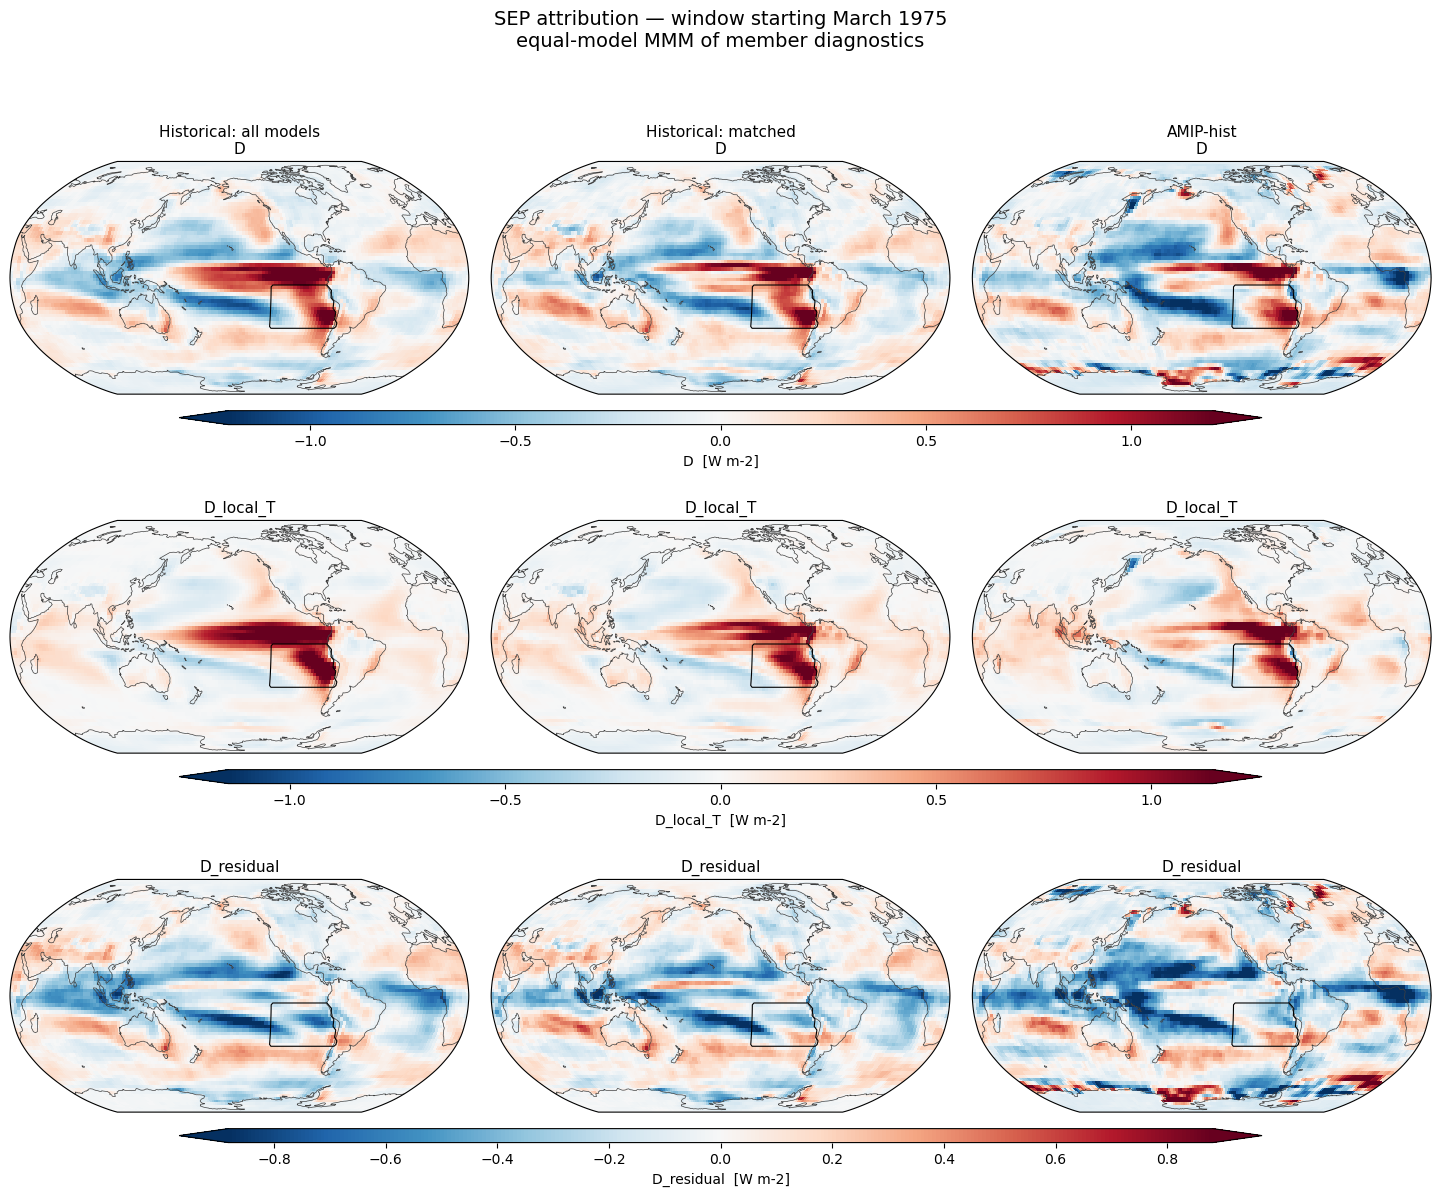

In [16]:
# %% 10. Running maps: choose any saved start year and any running-map quantities
attr_plot_year = 1975
fig_running, axes_running = plot_attr_maps(["D", "D_local_T", "D_residual"], start_year=attr_plot_year)
plt.show()

# Temperature co-variability / radiation amplitude, for example:
# plot_attr_maps(['cov_A_Zi', 'sigma_Ri', 'cov_A_Qi'], start_year=1900)
# plot_attr_maps(['cov_Zi_T', 'cov_Qi_R'], start_year=2000, experiments=['amip_hist'])
# plot_attr_maps(['D'], start_year=2000, model='TaiESM1', member=0, experiments=['amip_hist'])


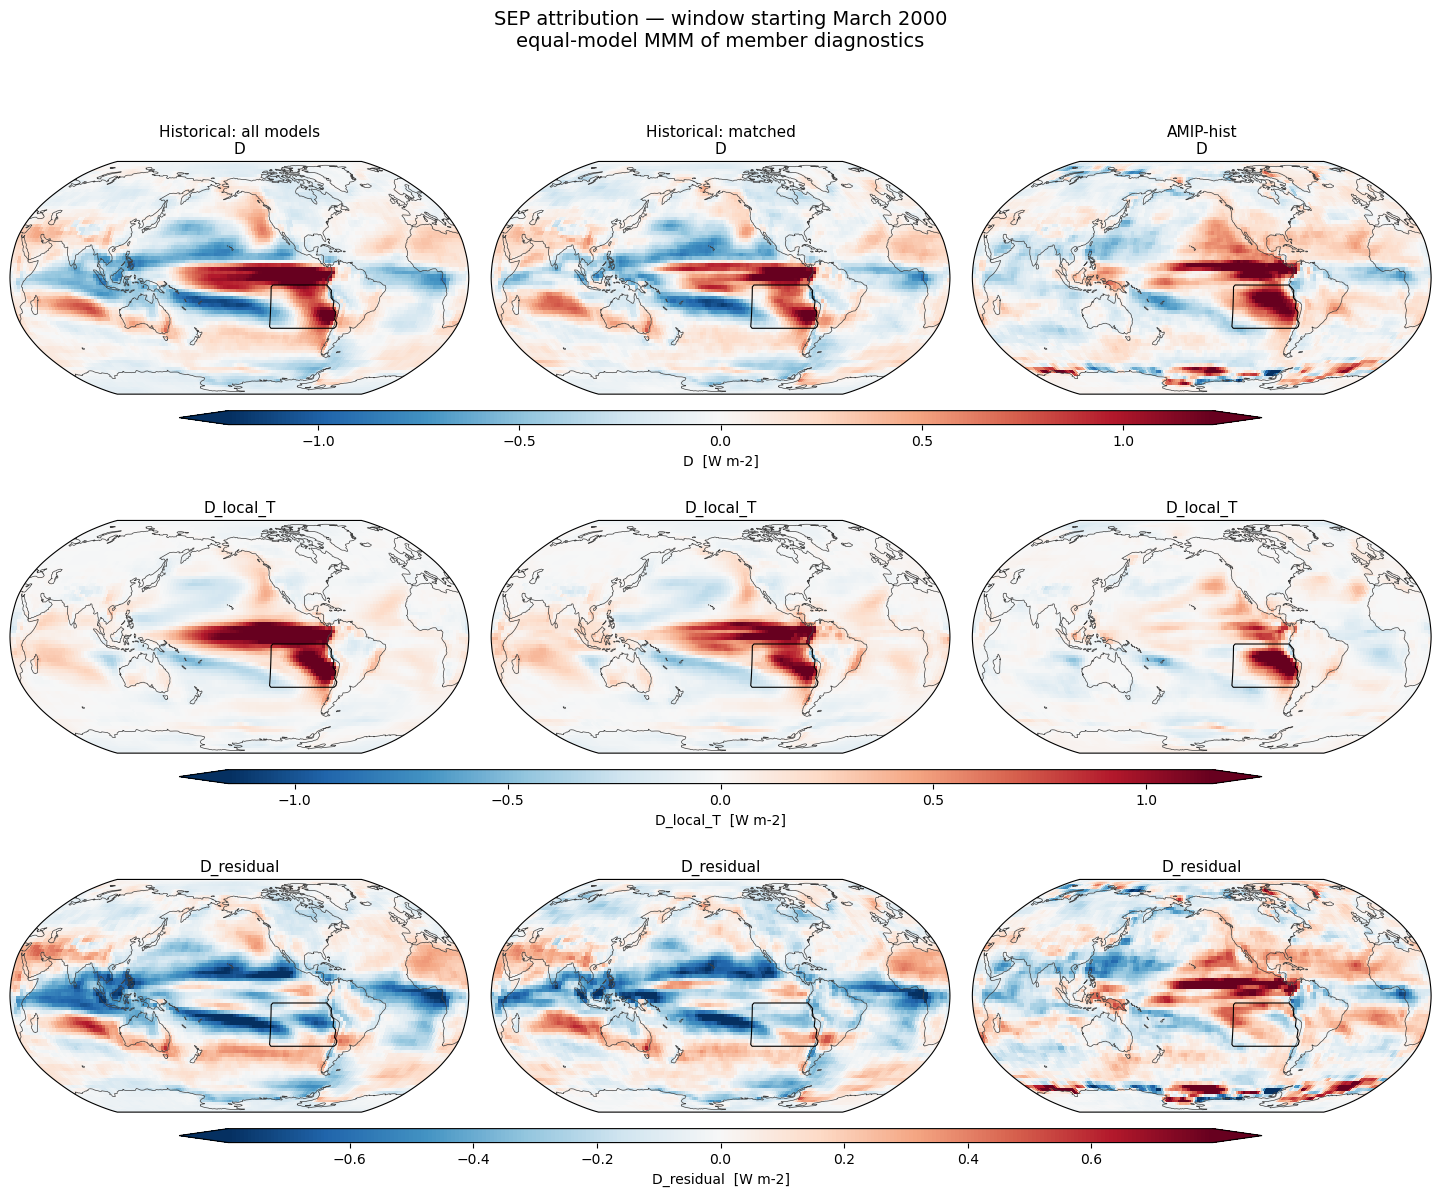

In [15]:
# %% 10. Running maps: choose any saved start year and any running-map quantities
attr_plot_year = 2000
fig_running, axes_running = plot_attr_maps(["D", "D_local_T", "D_residual"], start_year=attr_plot_year)
plt.show()

# Temperature co-variability / radiation amplitude, for example:
# plot_attr_maps(['cov_A_Zi', 'sigma_Ri', 'cov_A_Qi'], start_year=1900)
# plot_attr_maps(['cov_Zi_T', 'cov_Qi_R'], start_year=2000, experiments=['amip_hist'])
# plot_attr_maps(['D'], start_year=2000, model='TaiESM1', member=0, experiments=['amip_hist'])




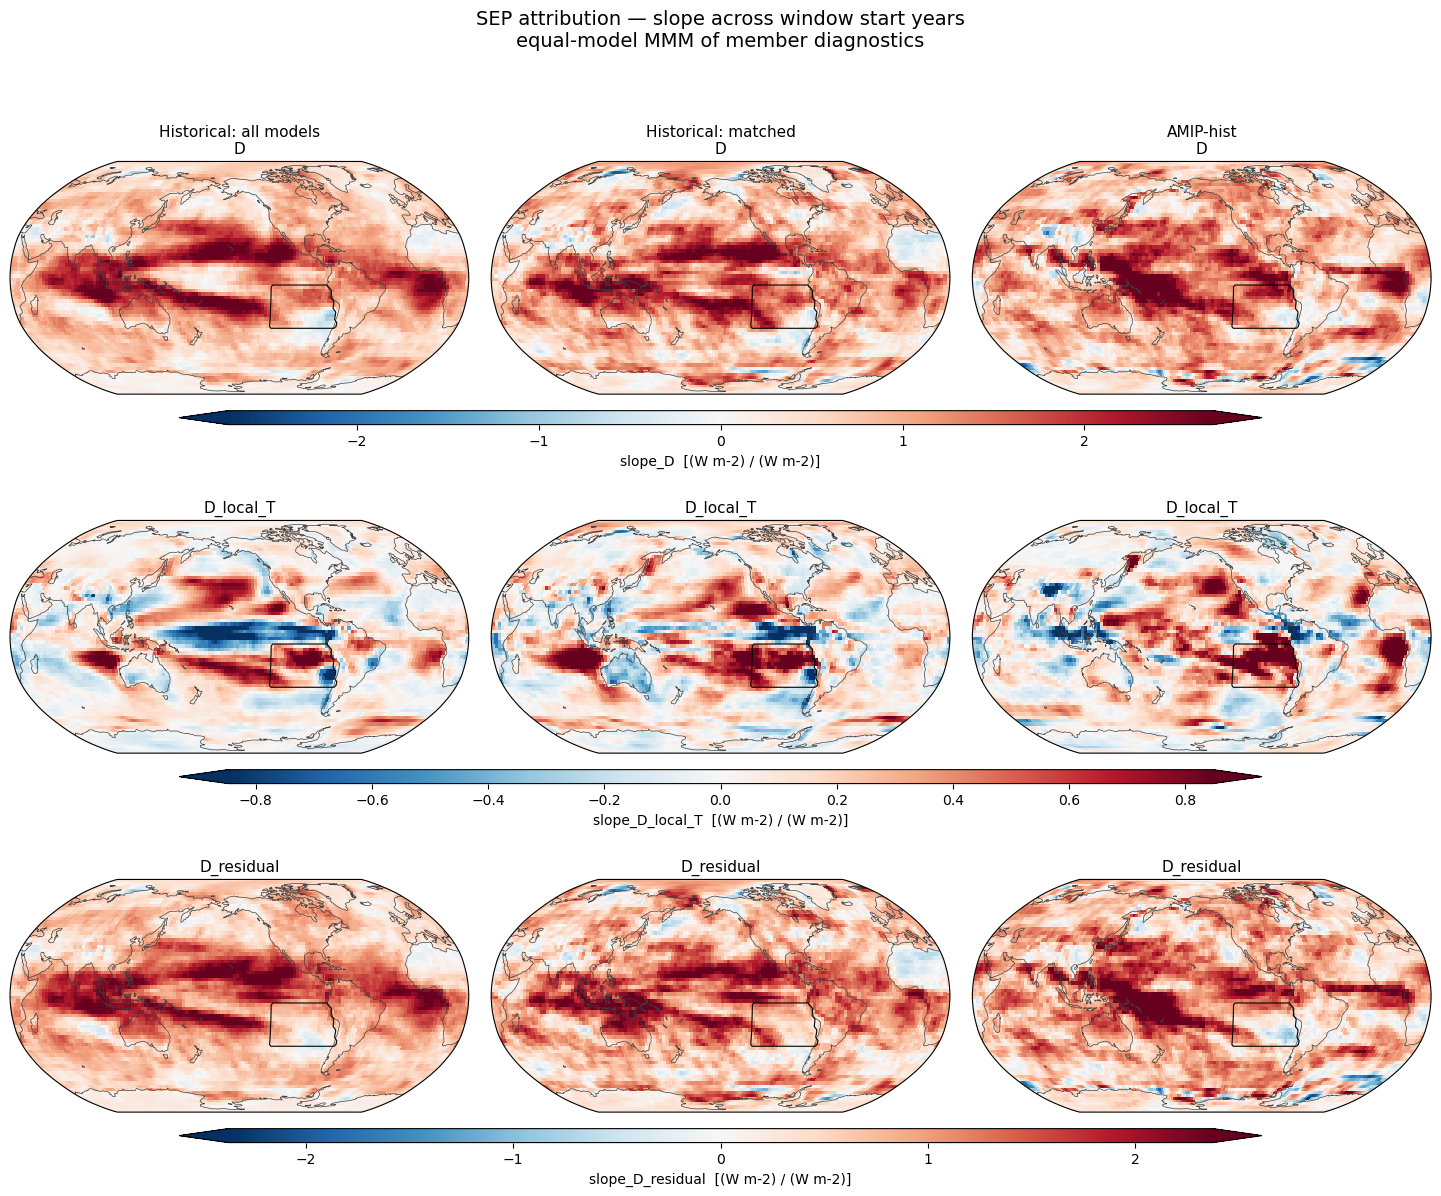

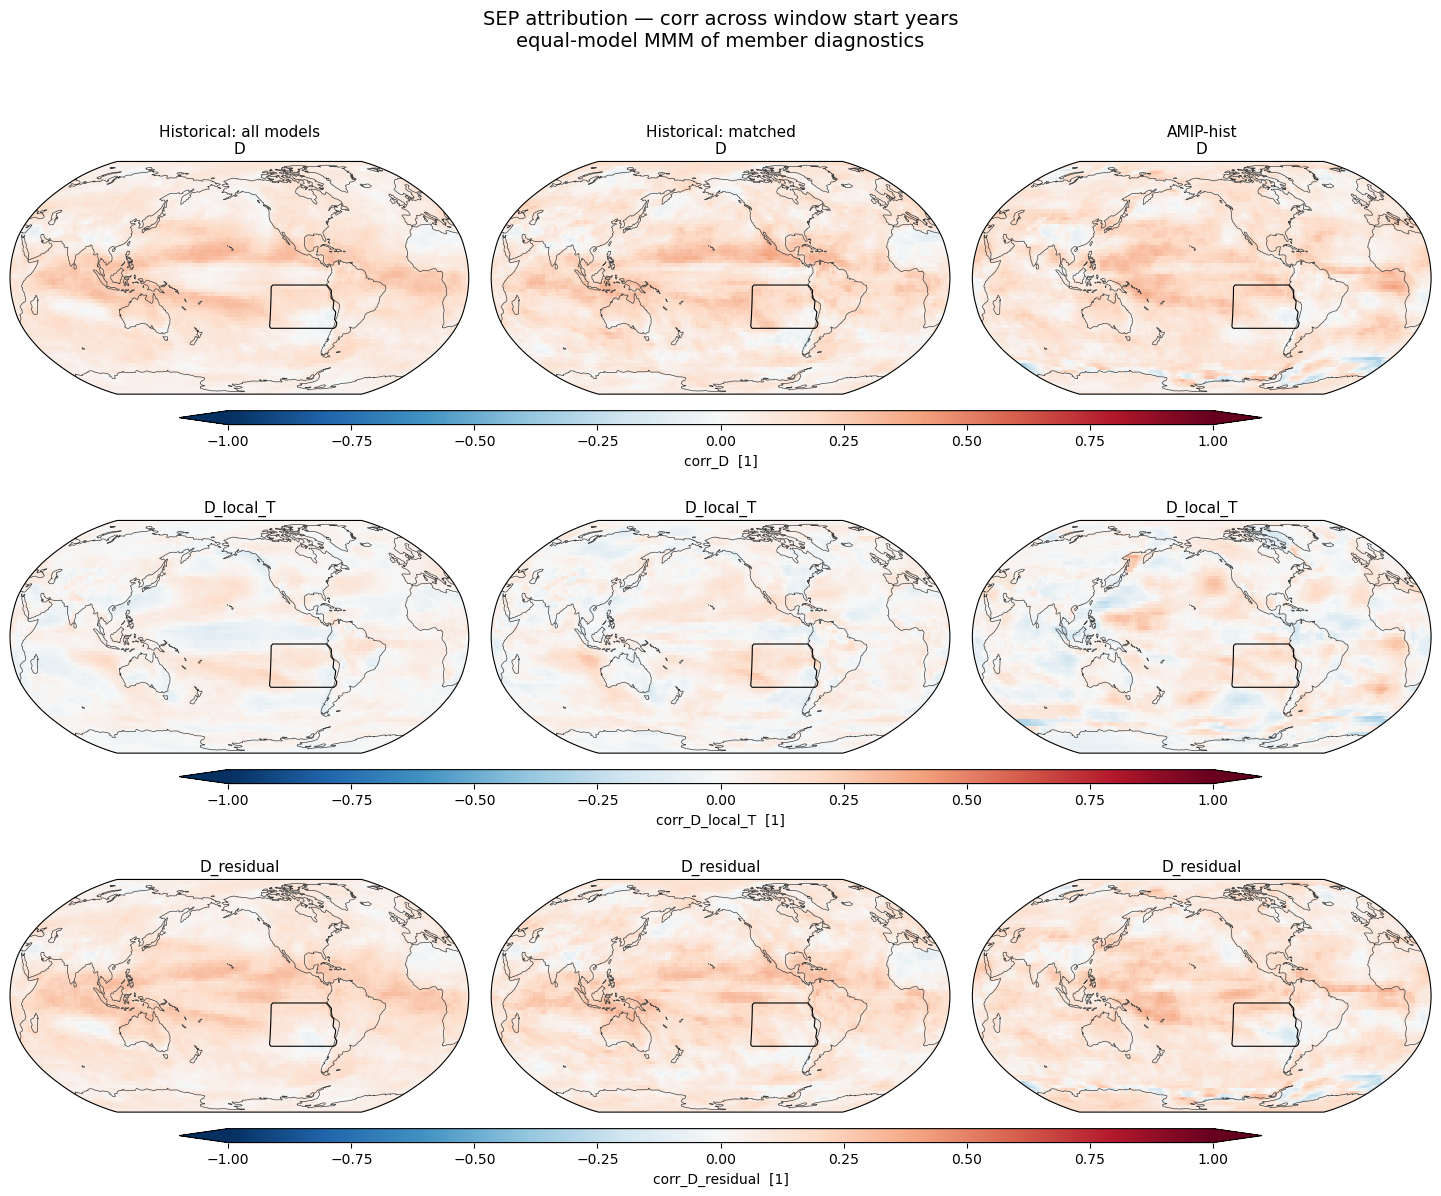

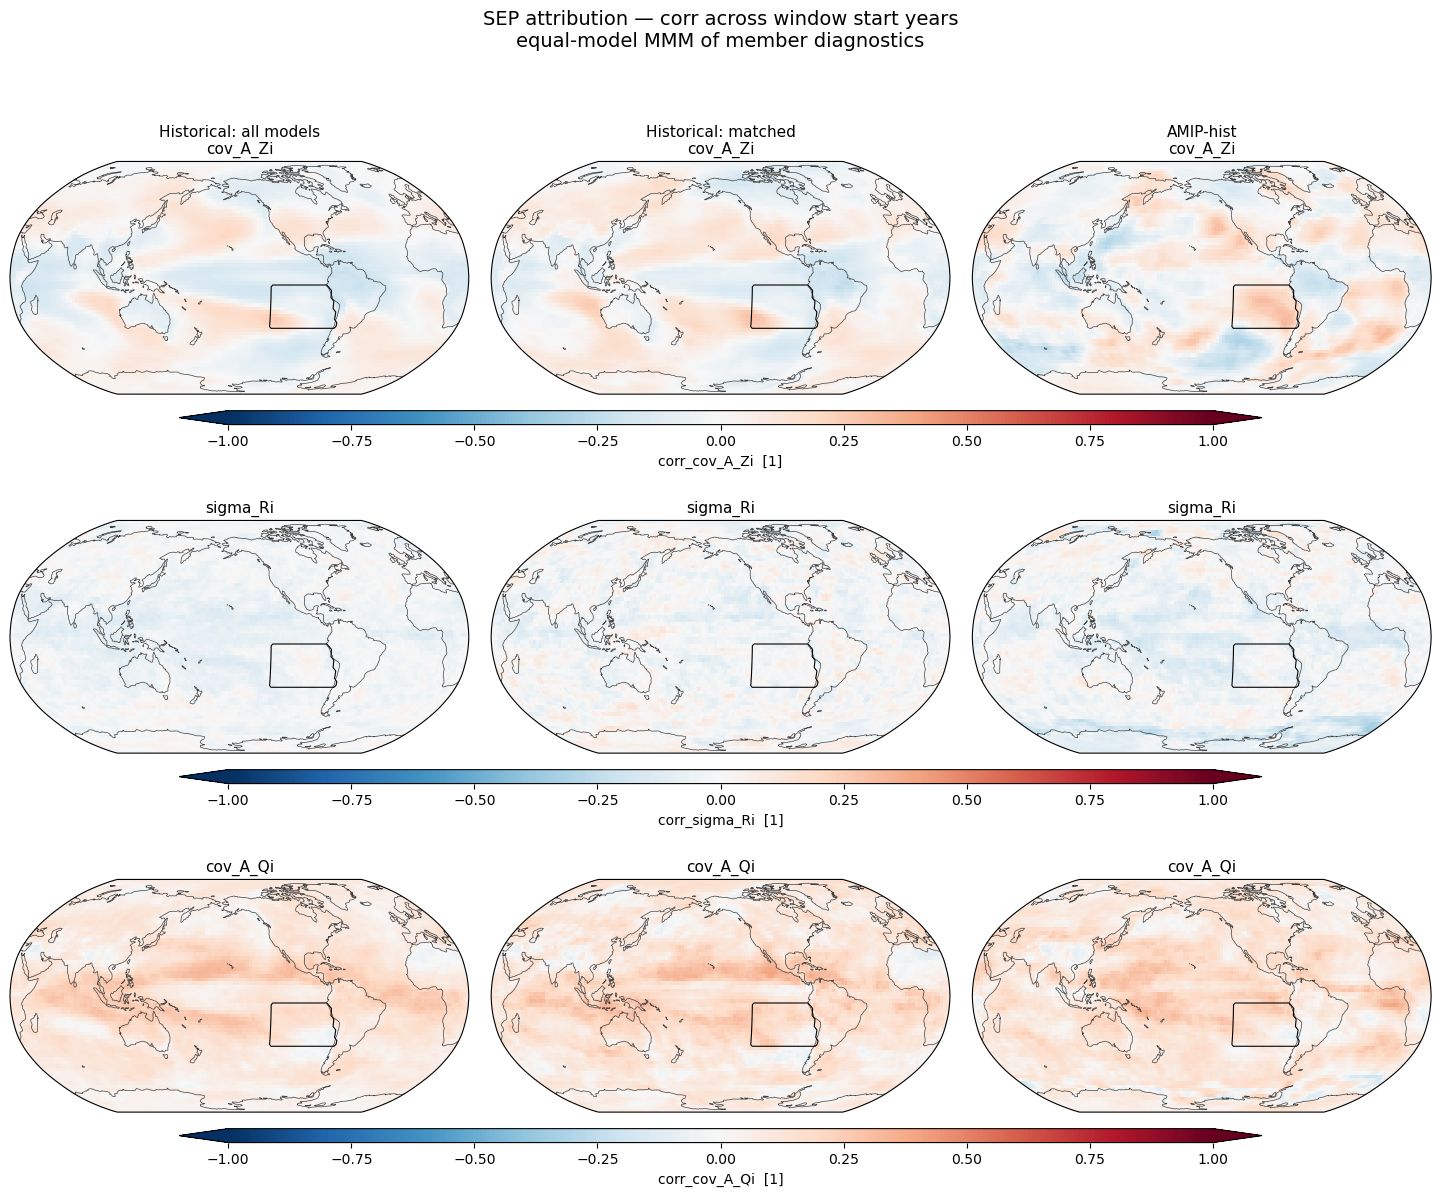

In [12]:
# %% 11. Across-window regression and correlation maps (all three experiments)
# The slope maps add: slope_D = slope_D_local_T + slope_D_residual. Their global
# area integrals are contributions to a one-unit increase in I; they can be
# negative or exceed one through cancellation. Correlations DO NOT add.
fig_slopes, axes_slopes = plot_attr_maps(["D", "D_local_T", "D_residual"], statistic="slope")
plt.show()
fig_corrs, axes_corrs = plot_attr_maps(["D", "D_local_T", "D_residual"], statistic="corr")
plt.show()
fig_context, axes_context = plot_attr_maps(["cov_A_Zi", "sigma_Ri", "cov_A_Qi"], statistic="corr")
plt.show()

# Other saved relationships need only a different quantity list:
# plot_attr_maps(['cov_Zi_T', 'cov_Qi_R', 'cov_Zi_Ri'], statistic='corr')
# plot_attr_maps(['cov_A_Ti', 'sigma_Ti'], statistic='slope_per_index_sd')
# plot_attr_maps(['D'], statistic='corr', savepath=attr_run_dir/'figures/corr_D.png')




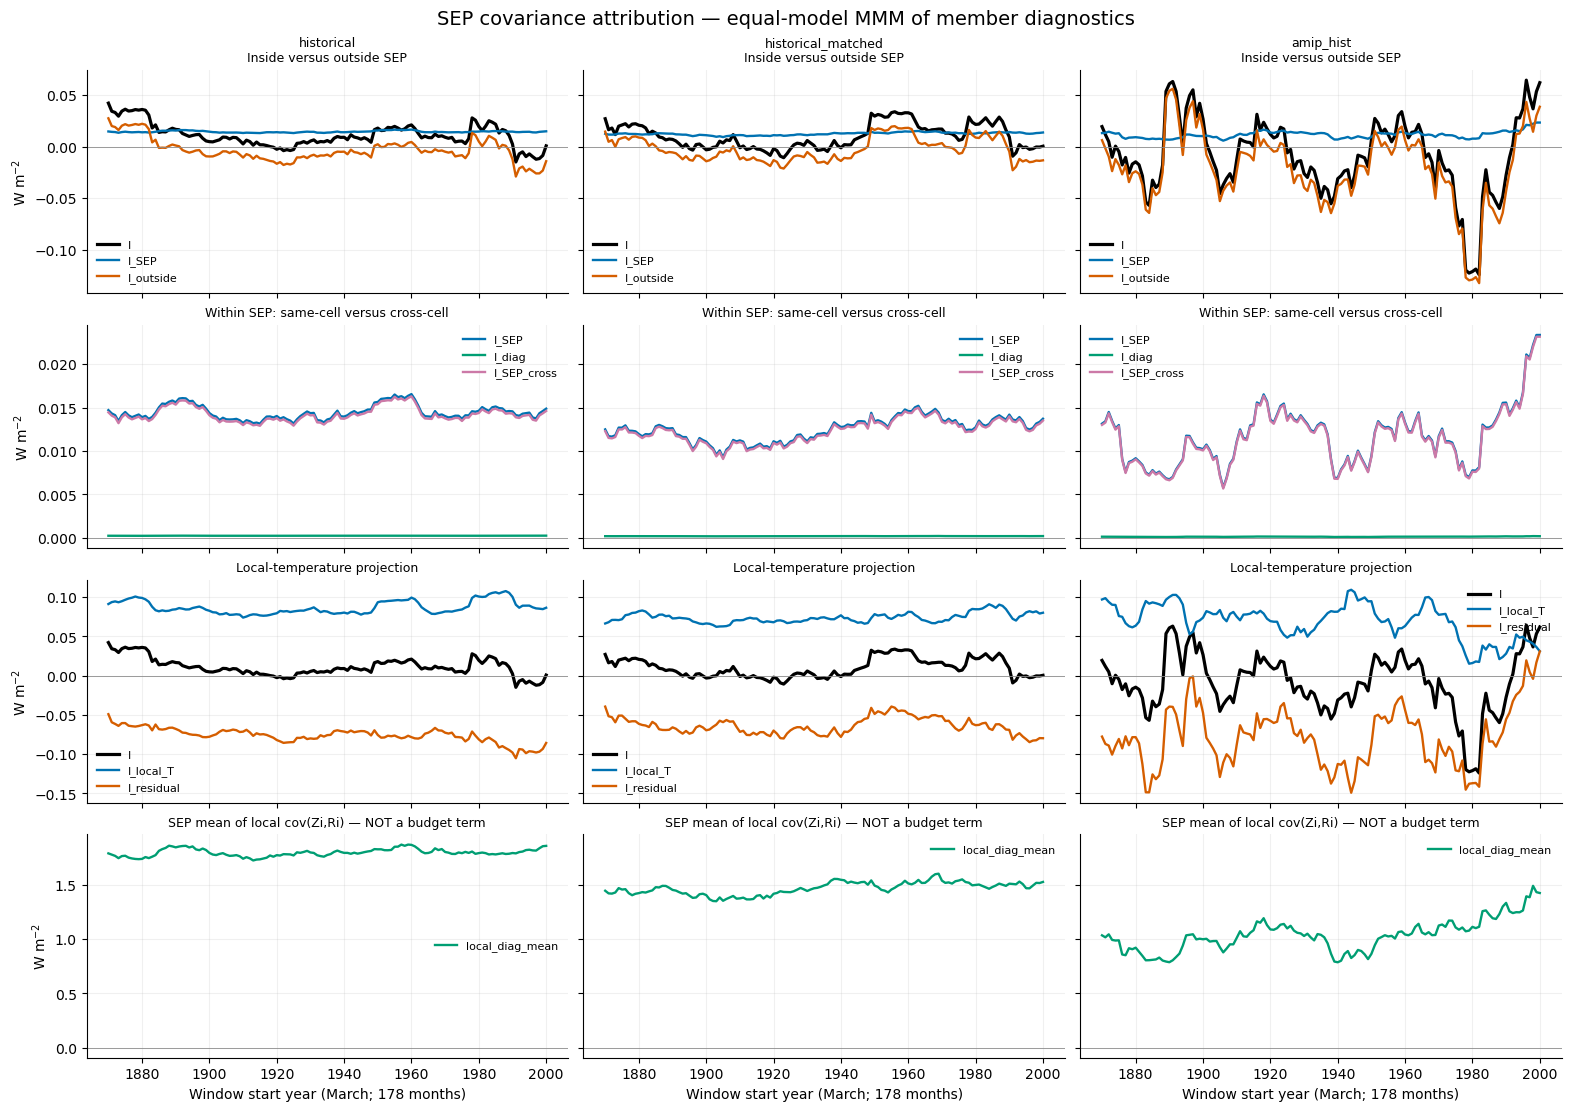

In [13]:
# %% 12. Running scalar budgets: where the decadal changes originate statistically
attr_plot_experiments = list(attr_catalog["model_names"])
attr_plot_years = attr_catalog["coordinates"]["start_year"]
attr_budget_rows = [
    (["I", "I_SEP", "I_outside"], "Inside versus outside SEP"),
    (["I_SEP", "I_diag", "I_SEP_cross"], "Within SEP: same-cell versus cross-cell"),
    (["I", "I_local_T", "I_residual"], "Local-temperature projection"),
    (["local_diag_mean"], "SEP mean of local cov(Zi,Ri) — NOT a budget term"),
]
attr_line_colors = {"I": "black", "I_SEP": "#0072B2", "I_outside": "#D55E00", "I_diag": "#009E73",
                    "I_SEP_cross": "#CC79A7", "I_local_T": "#0072B2", "I_residual": "#D55E00", "local_diag_mean": "#009E73"}
fig_budgets, axes_budgets = plt.subplots(4, len(attr_plot_experiments), figsize=(5.2*len(attr_plot_experiments), 11),
                                        sharex=True, sharey="row", squeeze=False, layout="constrained")
for col, experiment in enumerate(attr_plot_experiments):
    bundle = load_attr_bundle(experiment)
    for row, (keys, label) in enumerate(attr_budget_rows):
        ax = axes_budgets[row, col]
        for key in keys:
            ax.plot(attr_plot_years, bundle["values"][key], label=key, color=attr_line_colors[key], lw=2.3 if key == "I" else 1.7)
        ax.axhline(0, color=".55", lw=.6)
        ax.grid(alpha=.18)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_title((experiment + "\n" if row == 0 else "") + label, fontsize=9)
        ax.legend(fontsize=8, frameon=False)
        if col == 0:
            ax.set_ylabel(r"W m$^{-2}$")
        if row == 3:
            ax.set_xlabel("Window start year (March; 178 months)")
    del bundle
fig_budgets.suptitle("SEP covariance attribution — equal-model MMM of member diagnostics", fontsize=14)
plt.show()
fig_budgets.savefig(attr_run_dir/'budgets.png', dpi=220, bbox_inches='tight')
